/var/folders/lx/0h760fjj75g65qlknyyvp6y00000gp/T/ipykernel_58171/3826921262.py:50: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node = create_react_agent(llm,tools=Tool)


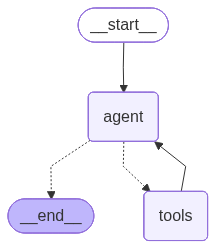

In [8]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,Annotated,Sequence
from langgraph.prebuilt import create_react_agent
from langchain_community.tools import WikipediaQueryRun,ArxivQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_community.tools import Tool
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.graph.message import add_messages

llm = ChatOpenAI(model="gpt-4o-mini")

def make_retrieval_tool_from_txt(file,name,desc):
    docs = TextLoader(file,encoding="utf-8").load()
    split_docs = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
    chunks = split_docs.split_documents(documents=docs)
    vs = FAISS.from_documents(embedding=OpenAIEmbeddings(),documents=chunks)
    retriever = vs.as_retriever()

    def tool_func(query:str)->str:
        print(f"Using Tool {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name=name,func=tool_func,description=desc)

internal_tool1 = make_retrieval_tool_from_txt("internaldocs.txt","Internal_Tool1","Explain about transformers")

internal_tool2 = make_retrieval_tool_from_txt("internaldocs_2.txt","Internal_Tool2","Explain me about Agents")

def arxiv_query(query:str)->str:
    api_wrapper = ArxivAPIWrapper()
    arxiv = ArxivQueryRun(api_wrapper=api_wrapper)
    return arxiv.run(query)

arxiv_tool = Tool(name="Arxiv",func=arxiv_query,description="This is to search arxiv database")

def wiki_query(query:str)->str:
    api_wrapper = WikipediaAPIWrapper()
    wiki = WikipediaQueryRun(api_wrapper=api_wrapper)
    return wiki.run(query)

wiki_tool = Tool(name="Wiki",func=wiki_query,description="This is to search wiki database")

Tool = [arxiv_tool,wiki_tool,internal_tool1,internal_tool2]

react_node = create_react_agent(llm,tools=Tool)

react_node

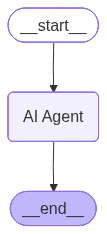

In [9]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]


builder = StateGraph(AgentState)

builder.add_node("AI Agent",react_node)
builder.set_entry_point("AI Agent")
builder.add_edge("AI Agent",END)

graph = builder.compile()

graph





In [11]:
query = "Explain me about transformers and what is recent news from arxiv about it?"

result = graph.invoke({"messages":[HumanMessage(content=query)]})

for message in result["messages"]:
    message.pretty_print()

Using Tool Internal_Tool1
================================ Human Message =================================

Explain me about transformers and what is recent news from arxiv about it?
================================== Ai Message ==================================
Tool Calls:
  Internal_Tool1 (call_71Mk56BYXiVB4hUTyjwsPwR4)
 Call ID: call_71Mk56BYXiVB4hUTyjwsPwR4
  Args:
    __arg1: transformers
  Arxiv (call_zQoOQ2pXvV4AtZDOSXeTs9Uw)
 Call ID: call_zQoOQ2pXvV4AtZDOSXeTs9Uw
  Args:
    __arg1: transformers
================================= Tool Message =================================
Name: Internal_Tool1

Transformer models are a class of neural network architectures widely used in natural language processing (NLP), computer vision, and generative AI systems. They are based on the attention mechanism, which allows models to focus on relevant parts of input data when generating outputs.

Since the introduction of the transformer architecture in the paper Attention Is All You Need by As

In [ ]:
import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")